In [93]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.utils import resample
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import tqdm
import matplotlib.pyplot as plt
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier
import datetime as dt
import joblib
import xarray as xr

In [21]:
def load_data():
    #Code from optimise_pss() in event_analysis.py
    
    #Load ERA5 environmental data at point locations
    model = pd.read_pickle("/g/data/eg3/ab4502/ExtremeWind/points/era5_allvars_v3_2005_2018.pkl").dropna()
    param_list = np.delete(np.array(model.columns), \
                    np.where((np.array(model.columns)=="lat") | \
                    (np.array(model.columns)=="lon") | \
                    (np.array(model.columns)=="loc_id") | \
                    (np.array(model.columns)=="time")))
    
    #Load observational data
    obs = pd.read_pickle("/g/data/eg3/ab4502/ExtremeWind/obs/aws/convective_wind_gust_aus_2005_2018.pkl")
    obs["hourly_ceil_utc"] = pd.DatetimeIndex(obs["gust_time_utc"]).ceil("1H")
    
    #Merge the observational data with the environmental data
    df_aws = pd.merge(obs[["stn_name","wind_gust","hourly_floor_utc","tc_affected","lightning","is_sta"]],\
        model, how="left",left_on=["stn_name","hourly_floor_utc"], right_on=["loc_id","time"]).dropna(subset=param_list).\
        dropna(subset=["wind_gust"])
    df_aws = df_aws[df_aws.tc_affected==0]
    
    #Create target variable
    df_aws.loc[:,"is_conv_aws"] = 0
    df_aws.loc[(df_aws.lightning >= 2) & (df_aws.wind_gust >= 25), "is_conv_aws"] = 1
    
    return df_aws

def train_binary_mod(df, classifier, preds, target):
    
    mod = classifier.fit(df[preds], df[target].values.ravel())
    
    return mod

def train_test_binary_mod(df, classifier, preds, target, n_split, test_size):
    
    auc_scores = []
    for train, test in tqdm.tqdm(StratifiedShuffleSplit(n_split,test_size=test_size).split(X=df[preds],y=df[target].values.ravel())):
        mod_split = train_binary_mod(df.iloc[train], classifier, preds, target)
        auc_scores.append(roc_auc_score(df.iloc[test][target],mod_split.predict_proba(df.iloc[test][preds])[:,1]))
        
    return auc_scores

def calc_bdsd(ds):
    ds["bdsd"] = 1 /\
                   ( 1 + np.exp( -(6.1e-02*ds["ebwd"] + 1.5e-01*ds["Umean800_600"] + 9.4e-01*ds["lr13"] + 3.9e-02*ds["rhmin13"] +
                                   1.7e-02*ds["srhe_left"] +3.8e-01*ds["q_melting"] +4.7e-04*ds["eff_lcl"] - 1.3e+01 ) ) )
    return ds

In [46]:
#Load data

env_var = ["ebwd","Umean800_600","lr13","rhmin13","srhe_left","q_melting","eff_lcl",\
          "qmean01","Umean06","s06","is_conv_aws"]
target="is_conv_aws"
df = load_data()
df = calc_bdsd(df)
np.random.seed(0)

In [49]:
#Separate into training and testing data
df_train = df[df.time < dt.datetime(2016,1,1)].copy()
df_test = df[df.time >= dt.datetime(2016,1,1)].copy()


In [50]:
#Try with all predictors and let the decision tree decide. As in our JSHESS paper, this is all "variables" (not including indices)
rf_preds = np.array(['ml_cape', 'mu_cape', 'sb_cape',\
             'ml_cin', 'sb_cin', 'mu_cin', 'ml_lcl', 'mu_lcl', 'sb_lcl', 'eff_cape',\
             'eff_cin', 'eff_lcl', 'lr01', 'lr03', 'lr13', 'lr36', 'lr24', 'lr_freezing',\
             'lr_subcloud', 'qmean01', 'qmean03', 'qmean06', 'qmeansubcloud', 'q_melting',\
             'q1', 'q3', 'q6', 'rhmin01', 'rhmin03', 'rhmin13', 'rhminsubcloud', 'tei', 'wbz',\
             'mhgt', 'mu_el', 'ml_el', 'sb_el', 'eff_el', 'pwat', \
             'te_diff', 'dpd850', 'dpd700', 'dcape', 'ddraft_temp', 'sfc_thetae',\
             'srhe_left', 'srh01_left', 'srh03_left', 'srh06_left', 'ebwd', 's010', 's06',\
             's03', 's01', 's13', 's36', 'scld', 'U500', 'U10', 'U1', 'U3', 'U6', 'Ust_left',\
             'Usr01_left', 'Usr03_left', 'Usr06_left', 'Uwindinf', 'Umeanwindinf',\
             'Umean800_600', 'Umean06', 'Umean01', 'Umean03'])
rf = BalancedRandomForestClassifier(n_estimators=100,
                                             max_depth=None,
                                             sampling_strategy='majority',
                                             max_features="sqrt"
                                            )
rf_mod = train_binary_mod(df_train,
                          rf,
                          rf_preds,
                          ["is_conv_aws"])

df_test["rf_clf"] = rf_mod.predict_proba(df_test[rf_preds])[:,1]

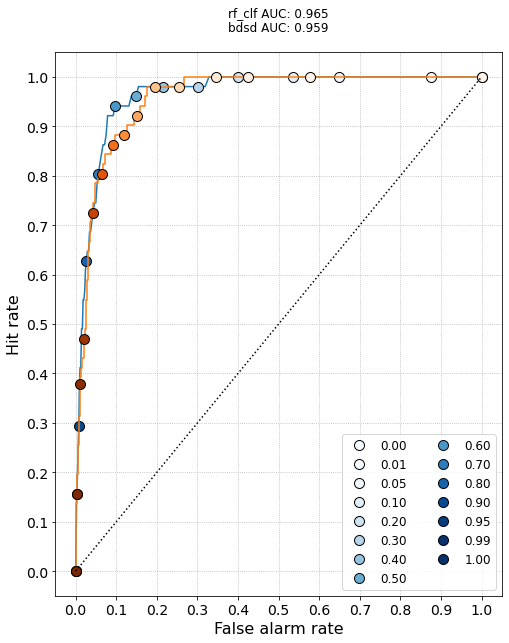

In [64]:
def interp_roc(x, fpr, tpr, thresholds):
    return np.interp(x, np.flip(thresholds), np.flip(fpr)), np.interp(x, np.flip(thresholds), np.flip(tpr))

def plot_roc(ax, df, target, predictors, cmaps, cols, markers=True):

    cnt=0
    title=""
    for predictor in predictors:
        fpr, tpr, thresholds = roc_curve(df[target],df[predictor])
        RocCurveDisplay(fpr=fpr,tpr=tpr).plot(ax=ax,color=cols[cnt])

        if markers:
            for t in [0.0,0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99,1.0]:
                x, y = interp_roc(t, fpr, tpr, thresholds)
                ax.plot(x, y, marker="o",label='%.2f' % (t), color=cmaps[cnt](t), mec="k", ls="none", ms=10)

            if cnt==0:
                plt.legend(fontsize=12,ncol=2)

            title = title + predictor+" AUC: "+str(roc_auc_score(df[target],df[predictor]).round(3))+"\n"
        cnt=cnt+1
    # opt_tss_x, opt_tss_y = interp_roc(opt_tss, fpr, tpr, thresholds)
    # ax.plot([0.5,opt_tss_x], [0.5,opt_tss_y], color="k", ls="--", label="Optimal TSS")
    # opt_csi_x, opt_csi_y = interp_roc(opt_csi, fpr, tpr, thresholds)
    # ax.plot([0.5,opt_csi_x], [0.5,opt_csi_y], color="tab:red", ls="--",label="Optimal CSI")         
    ax.plot([0,1],[0,1],color="k",ls=":")
    ax.grid(ls=":")
    ax.set_ylabel("Hit rate",size=16)
    ax.set_xlabel("False alarm rate",size=16)
    ax.tick_params("both",labelsize=14)
    ax.set_xticks(np.arange(0,1.1,.1))
    ax.set_yticks(np.arange(0,1.1,.1)) 
    ax.set_title(title)
    
plt.figure(figsize=[8,10])
plot_roc(plt.axes(),df_test,"is_conv_aws",["rf_clf","bdsd"],
         [plt.get_cmap("Blues"),plt.get_cmap("Oranges")],["tab:blue","tab:orange"])

20it [01:59,  5.95s/it]


Text(0.5, 1.0, '20 train-test splits using BDSD (orange, trained on all events)\nand RF classifier (blue, trained on training events)')

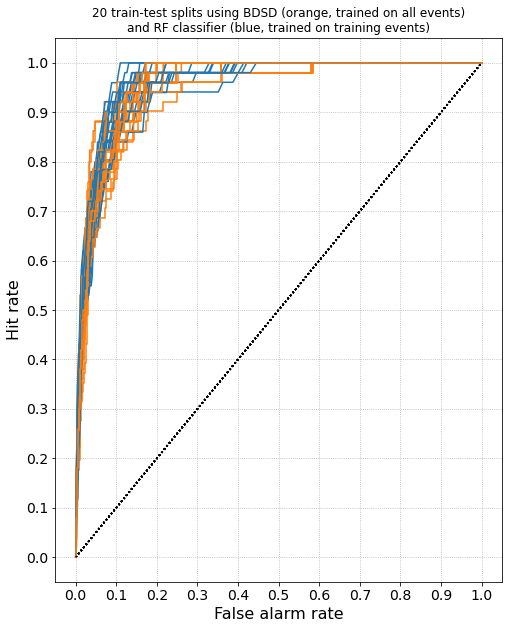

In [68]:
def train_test_binary_mod(df, classifier, preds, target, n_split, test_size):
    
    auc_scores = []
    for train, test in tqdm.tqdm(StratifiedShuffleSplit(n_split,test_size=test_size).split(X=df[preds],y=df[target].values.ravel())):
        mod_split = train_binary_mod(df.iloc[train], classifier, preds, target)
        #auc_scores.append(roc_auc_score(df.iloc[test][target],mod_split.predict_proba(df.iloc[test][preds])[:,1]))
        df["rf_clf"] = mod_split.predict_proba(df[preds])[:,1]
        plot_roc(plt.gca(),df.iloc[test],target,["rf_clf","bdsd"],[None,None],["tab:blue","tab:orange"],False)
    
    return auc_scores

plt.figure(figsize=[8,10])
auc_scores = train_test_binary_mod(df,
                                   rf_mod,
                                   rf_preds,
                                   ["is_conv_aws"],
                                   20,
                                   0.25)

plt.title("20 train-test splits using BDSD (orange, trained on all events)\n"+\
          "and RF classifier (blue, trained on training events)")

In [74]:
def skill(events, nulls, t, v, scores="TSS"):

    hits = (events[v]>t).sum()
    misses = (events[v]<=t).sum()
    fa = (nulls[v]>t).sum()
    cn = (nulls[v]<=t).sum()

    if scores=="TSS":
        return (( (hits) / (hits+misses) )  - ( (fa) / (fa+cn) ))
    elif scores=="CSI":
        return ((hits)  / (hits+misses+fa))
    elif scores=="HSS":
        if hits / (hits + misses) > 0.66:
            return (( 2*(hits*cn - misses*fa) ) / ( misses*misses + fa*fa + 2*hits*cn + (misses + fa) * (hits + cn) ))
        else:
            return (0)

def skill_test(scw,null,v,target="is_conv_aws",scores="TSS"):
    x = np.linspace(0,scw[v].quantile(1),100)
    if scores != "AUC":
        score = [skill(scw,null,i,v,scores=scores) for i in x]
    elif scores == "AUC":
        temp = pd.concat([scw[[v,target]], null[[v,target]]], axis=0)
        score = [roc_auc_score(temp[target],temp[v])]
        x = [np.nan]
    else:
        raise ValueError()

    return np.max(score), x[np.argmax(score)]



In [75]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="bdsd", scores="HSS")

(0.05354506803230668, 0.8484451987526633)

In [76]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="rf_clf", scores="HSS")

(0.05254361467489433, 0.7622222222222221)

In [77]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="bdsd", scores="AUC")

(0.9587159116520172, nan)

In [78]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="rf_clf", scores="AUC")

(0.9650890241153932, nan)

In [79]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="bdsd", scores="TSS")

(0.8018289384719405, 0.33331775665283203)

In [80]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="rf_clf", scores="TSS")

(0.8444235970250169, 0.5939393939393939)

In [81]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="bdsd", scores="CSI")

(0.05517241379310345, 0.9898527318781072)

In [82]:
skill_test(df_test[df_test["is_conv_aws"]==1],
           df_test[df_test["is_conv_aws"]==0],
           v="rf_clf", scores="CSI")

(0.06504065040650407, 0.9404040404040404)

In [95]:
#This is an example of how to load the RF classifier (from the 
#classification_model.ipynb model) and apply to ERA5
#Note this just fills NaNs with Zeros - would need to be improved

clf = joblib.load('/g/data/eg3/ab4502/ExtremeWind/rf_clf.joblib')
f = xr.open_dataset("/g/data/eg3/ab4502/ExtremeWind/aus/era5/era5_20200101_20200131.nc")

var = np.array(['ml_cape', 'mu_cape', 'sb_cape',\
             'ml_cin', 'sb_cin', 'mu_cin', 'ml_lcl', 'mu_lcl', 'sb_lcl', 'eff_cape',\
             'eff_cin', 'eff_lcl', 'lr01', 'lr03', 'lr13', 'lr36', 'lr24', 'lr_freezing',\
             'lr_subcloud', 'qmean01', 'qmean03', 'qmean06', 'qmeansubcloud', 'q_melting',\
             'q1', 'q3', 'q6', 'rhmin01', 'rhmin03', 'rhmin13', 'rhminsubcloud', 'tei', 'wbz',\
             'mhgt', 'mu_el', 'ml_el', 'sb_el', 'eff_el', 'pwat', \
             'te_diff', 'dpd850', 'dpd700', 'dcape', 'ddraft_temp', 'sfc_thetae',\
             'srhe_left', 'srh01_left', 'srh03_left', 'srh06_left', 'ebwd', 's010', 's06',\
             's03', 's01', 's13', 's36', 'scld', 'U500', 'U10', 'U1', 'U3', 'U6', 'Ust_left',\
             'Usr01_left', 'Usr03_left', 'Usr06_left', 'Uwindinf', 'Umeanwindinf',\
             'Umean800_600', 'Umean06', 'Umean01', 'Umean03'])
stacked = f.sel({"time":"2020-01-31 06:00"})[var].fillna(0).stack(space=("lat","lon")).to_array()
X = stacked.values
preds = clf.predict_proba(X.T)[:,1].reshape((f.lat.shape[0],f.lon.shape[0]))

Text(0.5, 1.0, 'Logistic Regression Classifier')

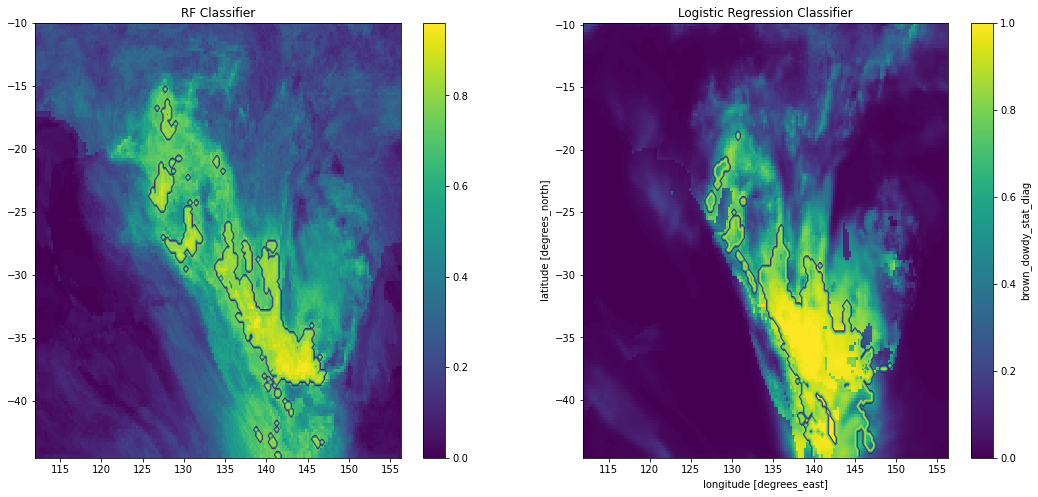

In [96]:
plt.figure(figsize=[18,8])

ax=plt.subplot(1,2,1)
x,y=np.meshgrid(f.lon.values, f.lat.values)
plt.pcolormesh(x,y,preds); plt.colorbar()
plt.contour(x,y,preds>0.76)
plt.title("RF Classifier")

ax=plt.subplot(1,2,2)
f.sel({"time":"2020-01-31 03:00"}).bdsd.plot(ax=ax)
plt.contour(x,y,f.sel({"time":"2020-01-31 06:00"}).bdsd>0.85)
plt.title("Logistic Regression Classifier")